# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera ? MLflow ? Optuna ? Evidently ? SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts ? at a cost of ?8?15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   ? 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` ? 1,499 readings from the current stable production batch
- `data/stress.csv`  ? 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [10]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_MLOps/data/train.csv')
current = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_MLOps/data/current.csv')
stress  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_MLOps/data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


In [37]:
print("\n--- Statistical details for 'train' dataset ---")
display(train.describe())

print("\n--- Statistical details for 'current' dataset ---")
display(current.describe())

print("\n--- Statistical details for 'stress' dataset ---")
display(stress.describe())


--- Statistical details for 'train' dataset ---


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type,Power_W,Temp_diff,Type_enc
count,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000
mean,300.011626,310.004891,1539.017589,39.995796,107.679108,0.089518,6281.464568,9.993265,1.195624
std,2.004642,1.481363,179.909994,9.977137,63.818988,0.519357,1067.209431,1.000721,0.599436
min,295.300000,305.700000,1168.000000,4.200000,0.000000,0.000000,1264.051220,7.600000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,52.000000,0.000000,5561.770914,9.200000,1.000000
50%,300.100000,310.100000,1504.000000,40.100000,107.000000,0.000000,6266.890913,9.800000,1.000000
75%,301.500000,311.100000,1614.000000,46.800000,163.000000,0.000000,7013.417104,11.000000,2.000000
max,304.500000,313.800000,2874.000000,76.200000,253.000000,4.000000,10112.074658,12.100000,2.000000



--- Statistical details for 'current' dataset ---


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type,Power_W,Temp_diff,Type_enc
count,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000
mean,299.922815,310.004470,1530.165444,40.219613,108.200133,0.090060,6295.646700,10.081654,1.222815
std,1.931466,1.448087,167.707313,9.755529,63.534900,0.521143,1051.192458,0.993673,0.607903
min,295.300000,305.800000,1200.000000,3.800000,0.000000,0.000000,1148.440610,7.600000,0.000000
25%,298.400000,308.900000,1420.500000,33.700000,56.000000,0.000000,5609.617370,9.300000,1.000000
50%,300.000000,310.100000,1499.000000,40.200000,108.000000,0.000000,6292.767165,9.900000,1.000000
75%,301.300000,311.100000,1596.000000,46.700000,162.000000,0.000000,6965.916223,11.000000,2.000000
max,304.400000,313.600000,2886.000000,76.600000,251.000000,4.000000,10058.123040,12.000000,2.000000



--- Statistical details for 'stress' dataset ---


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type,Power_W,Temp_diff,Type_enc
count,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000
mean,300.053836,310.008606,1497.074716,44.724083,148.869913,0.205470,6836.225193,9.954770,1.192795
std,2.046134,1.531925,188.175613,10.222344,62.565552,0.835908,986.640188,1.006525,0.595534
min,295.400000,305.900000,1162.000000,14.300000,23.000000,0.000000,3879.741263,7.600000,0.000000
25%,298.400000,308.800000,1377.000000,37.850000,96.500000,0.000000,6141.813638,9.200000,1.000000
50%,300.200000,310.100000,1457.000000,45.000000,150.000000,0.000000,6831.141898,9.800000,1.000000
75%,301.650000,311.100000,1572.500000,51.600000,201.500000,0.000000,7500.185941,10.900000,2.000000
max,304.400000,313.700000,2662.000000,79.400000,250.000000,4.000000,10551.415918,12.100000,2.000000


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [7]:
#!pip install pandera

import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    "Type": pa.Column(str, Check.isin(["L", "M", "H"])),
    "Air temperature": pa.Column(float, Check.in_range(295.0, 305.0)),
    "Process temperature": pa.Column(float, Check.in_range(305.0, 315.0)),
    "Rotational speed": pa.Column(int, Check.in_range(1000, 2900)),
    "Torque": pa.Column(float, Check.in_range(3.0, 80.0)),
    "Tool wear": pa.Column(int, Check.in_range(0, 253)),
    "Failure_Type": pa.Column(int, Check.isin([0, 1, 2, 3, 4]))
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)

# TODO: Validate stress with lazy=True and print violation summary
try:
    schema.validate(stress, lazy=True)
    print("Schema validated")
except pa.errors.SchemaErrors as err:
    print(f"Schema violations found in stress.csv: {len(err.failure_cases)} cases")
    display(err.failure_cases)

Schema validated


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Failure_Type Distribution:
Failure_Type
0    6762
2      76
4      69
3      56
1      30
Name: count, dtype: int64

Is the class distribution balanced? No, it is highly imbalanced, with 'No Failure' (0) dominating.


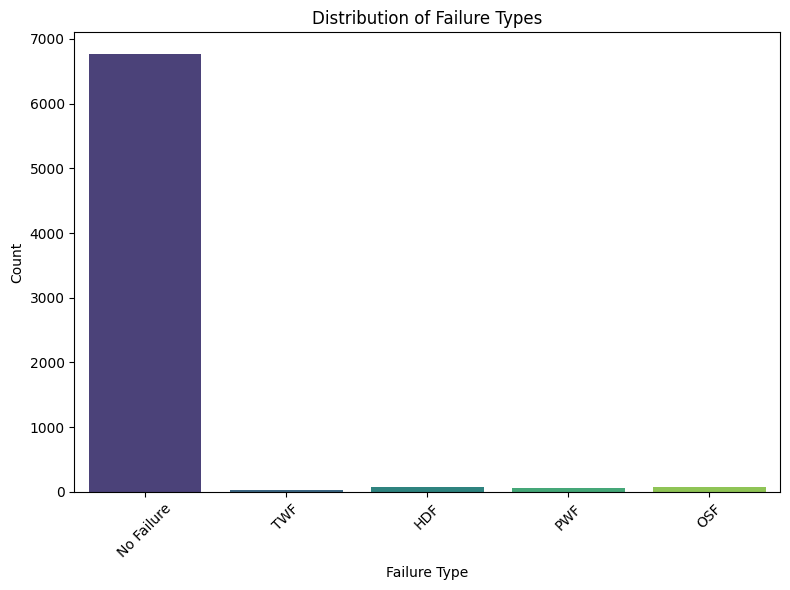

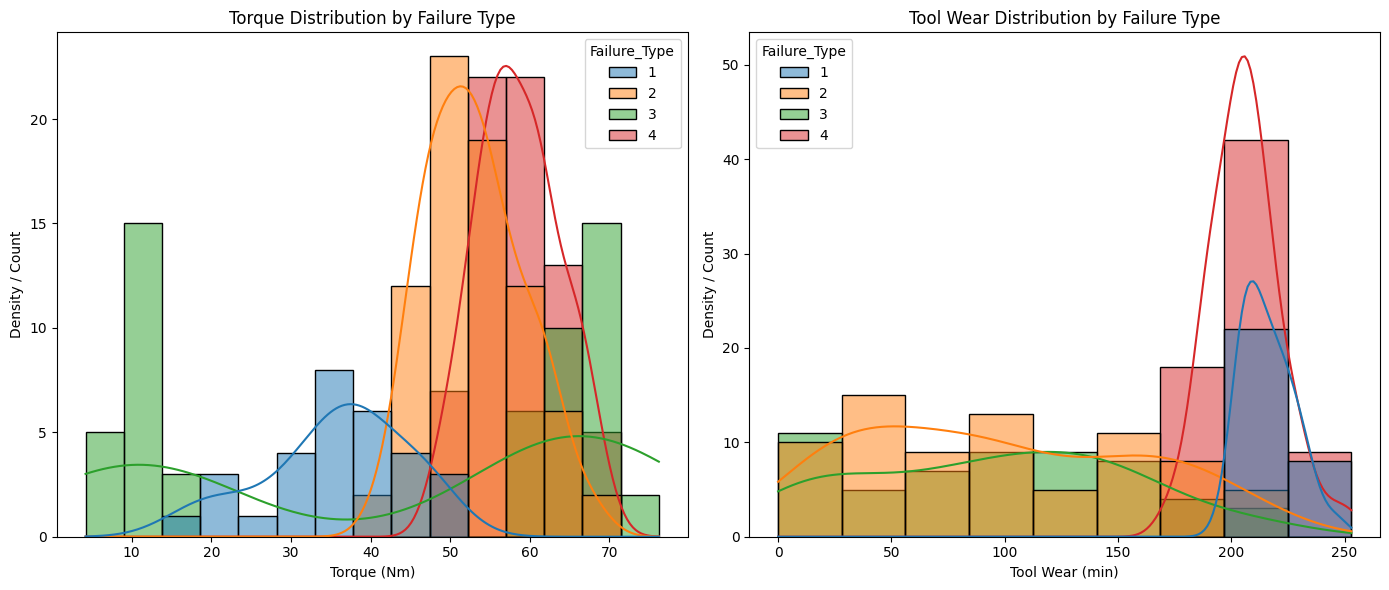


Type (L/M/H) Distribution:
Type
L    4213
M    2074
H     706
Name: count, dtype: int64


In [11]:
# 1. Print the class distribution of Failure_Type. Is it balanced?
print("Failure_Type Distribution:")
print(train['Failure_Type'].value_counts())
print("\nIs the class distribution balanced? No, it is highly imbalanced, with 'No Failure' (0) dominating.")

# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=train, x='Failure_Type', palette='viridis')
plt.title('Distribution of Failure Types')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(ticks=range(len(CLASS_NAMES)), labels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())], rotation=45)
plt.tight_layout()
plt.show()

# 2. Plot the distribution of Torque and Tool wear split by failure class (failures only).
# Filter for failure types (1, 2, 3, 4)
failure_df = train[train['Failure_Type'] != 0]

plt.figure(figsize=(14, 6))

# Torque distribution by failure type
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data=failure_df, x='Torque', hue='Failure_Type', kde=True, palette='tab10')
plt.title('Torque Distribution by Failure Type')
plt.xlabel('Torque (Nm)')
plt.ylabel('Density / Count')

# Tool wear distribution by failure type
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(data=failure_df, x='Tool wear', hue='Failure_Type', kde=True, palette='tab10')
plt.title('Tool Wear Distribution by Failure Type')
plt.xlabel('Tool Wear (min)')
plt.ylabel('Density / Count')

plt.tight_layout()
plt.show()

# 3. Print the Type (L/M/H) distribution.
print("\nType (L/M/H) Distribution:")
print(train['Type'].value_counts())

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [12]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = df['Torque'] * (df['Rotational speed'] * 2 * np.pi) / 60
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
print("Mean of new features grouped by Failure_Type:")
print(train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean())

Mean of new features grouped by Failure_Type:
                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Post-SMOTE training set class distribution:")
print(y_res.value_counts())

Post-SMOTE training set class distribution:
Failure_Type
0    5409
3    5409
4    5409
2    5409
1    5409
Name: count, dtype: int64


*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE (Synthetic Minority Over-sampling Technique) is applied only to the training data to prevent data leakage. If SMOTE were applied to the validation set, the model would be evaluated on synthetic samples that are closely related to the training data, leading to an overly optimistic and unrealistic estimate of the model's performance on unseen data. The validation set must remain untouched to serve as an unbiased evaluation of the model's generalization capability.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [14]:
#!pip install mlflow

import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])

for model_name, model in models_to_run.items():
    with mlflow.start_run(run_name=model_name):
        # Log model parameter
        mlflow.log_param('model', model_name)

        # Fit the model
        model.fit(X_res, y_res)

        # Predict on validation set
        y_pred = model.predict(X_val)

        # Compute metrics
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')
        accuracy = accuracy_score(y_val, y_pred)
        per_class_f1 = f1_score(y_val, y_pred, average=None, labels=CLASS_LIST)

        # Log metrics
        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy', accuracy)
        for i, f1 in enumerate(per_class_f1):
            mlflow.log_metric(f'f1_class_{i}', f1)

        # Log model artifact
        mlflow.sklearn.log_model(model, 'model', input_example=X_val.iloc[:5].to_numpy())

        results[model_name] = {
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'accuracy': accuracy,
            **{f'f1_class_{i}': f1 for i, f1 in enumerate(per_class_f1)}
        }

# Print comparison table
print("\nModel Comparison Table:")
results_df = pd.DataFrame(results).T
print(results_df)

# Identify best model by macro F1
best_model_name = results_df['macro_f1'].idxmax()
best_macro_f1 = results_df['macro_f1'].max()
print(f"\nBest model by macro F1: {best_model_name} with macro F1: {best_macro_f1:.4f}")

2026/05/03 16:37:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 16:37:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/03 16:37:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 16:37:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p


Model Comparison Table:
                    macro_f1  weighted_f1  accuracy  f1_class_0  f1_class_1  \
LogisticRegression  0.531231     0.932771  0.904217    0.948350    0.144928   
RandomForest        0.735542     0.985459  0.984989    0.992614    0.000000   
XGBoost             0.748062     0.985147  0.984274    0.992231    0.133333   
LightGBM            0.729645     0.985088  0.984274    0.992231    0.000000   

                    f1_class_2  f1_class_3  f1_class_4  
LogisticRegression    0.454545    0.458333    0.650000  
RandomForest          0.928571    0.956522    0.800000  
XGBoost               0.965517    0.880000    0.769231  
LightGBM              0.965517    0.833333    0.857143  

Best model by macro F1: XGBoost with macro F1: 0.7481


# **Observation**

F1-score for class 1 (Tool Wear Failure, TWF) is 0.0 for most models, even after applying techniques like SMOTE and hyperparameter tuning. This indicates a significant challenge in correctly identifying this particular failure type.

The primary reason for an F1-score of 0.0 for class 1 is **extreme data scarcity** combined with the inherent difficulty of learning from so few examples.

Here's a breakdown:

1.  **Original Class Imbalance:** In the original `train.csv` dataset, `Failure_Type` 1 (TWF) has only **30 samples** out of nearly 7000 total instances. This is an extremely rare minority class.

2.  **Validation Set Size:** When the data is split into 80% training and 20% validation, the validation set (`y_val`) would contain only about **6 samples** belonging to class 1 (20% of 30). This is a tiny number of instances for the model to be evaluated on.

3.  **SMOTE's Limitation:** While SMOTE (Synthetic Minority Over-sampling Technique) helps to balance the *training* data by creating synthetic samples, it **does not affect the validation set**. The model learns from a balanced training set, but it is still evaluated on the original, imbalanced validation set.

4.  **Inability to Generalize:** With only 6 real instances of TWF in the validation set, it's highly probable that the model, despite being trained with SMOTE, fails to correctly predict *any* of these 6 instances. If the model predicts zero true positives for class 1 (meaning it never correctly identifies a TWF instance) or zero predicted positives (meaning it never predicts TWF at all), both the precision and recall for that class will be zero, leading to an F1-score of 0.0.

In essence, the model struggles to generalize effectively to these extremely rare real-world examples, causing it to miss all actual occurrences in the validation set.

### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [15]:
#!pip install optuna

import optuna
import joblib
import mlflow

optuna.logging.set_verbosity(optuna.logging.WARNING);
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }

    with mlflow.start_run():
        mlflow.log_params(params)
        model = XGBClassifier(**params)
        model.fit(X_res, y_res)
        y_pred = model.predict(X_val)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        mlflow.log_metric('macro_f1', macro_f1)
    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

print(f"Best trial:")
print(f"  Value: {study.best_value:.4f}")
print(f"  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train final best model
best_tuned_model = XGBClassifier(**study.best_params, random_state=42, eval_metric='mlogloss', verbosity=0)
best_tuned_model.fit(X_res, y_res)

# Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
with mlflow.start_run(run_name="Best_XGBoost_Tuned"):
    mlflow.log_params(study.best_params)
    y_pred_tuned = best_tuned_model.predict(X_val)
    macro_f1_tuned = f1_score(y_val, y_pred_tuned, average='macro')
    weighted_f1_tuned = f1_score(y_val, y_pred_tuned, average='weighted')
    accuracy_tuned = accuracy_score(y_val, y_pred_tuned)
    per_class_f1_tuned = f1_score(y_val, y_pred_tuned, average=None, labels=CLASS_LIST)

    mlflow.log_metric('macro_f1', macro_f1_tuned)
    mlflow.log_metric('weighted_f1', weighted_f1_tuned)
    mlflow.log_metric('accuracy', accuracy_tuned)
    for i, f1 in enumerate(per_class_f1_tuned):
        mlflow.log_metric(f'f1_class_{i}', f1)

    # Register the model
    model_info = mlflow.sklearn.log_model(
        sk_model=best_tuned_model,
        artifact_path='PredMaint_XGBoost_model',
        registered_model_name='PredMaint_XGBoost',
        input_example=X_val.iloc[:5].to_numpy()
    )

    # Promote to production alias
    client = mlflow.tracking.MlflowClient()
    # Get the latest version of the registered model explicitly
    latest_version = client.get_latest_versions("PredMaint_XGBoost", stages=["None"])[0].version
    client.set_registered_model_alias(name='PredMaint_XGBoost', alias='production', version=latest_version)
    print(f"Registered model 'PredMaint_XGBoost' version {latest_version} with alias 'production'")

# Save with joblib.dump
joblib.dump(best_tuned_model, 'best_model.pkl')
print("Best model saved as best_model.pkl")

# Print the improvement in macro F1 over the baseline XGBoost
baseline_macro_f1 = results_df.loc['XGBoost', 'macro_f1']
macro_f1_improvement = macro_f1_tuned - baseline_macro_f1
print(f"\nBaseline XGBoost Macro F1: {baseline_macro_f1:.4f}")
print(f"Tuned XGBoost Macro F1: {macro_f1_tuned:.4f}")
print(f"Macro F1 Improvement over baseline XGBoost: {macro_f1_improvement:.4f}")

Best trial:
  Value: 0.7672
  Params: 
    n_estimators: 407
    max_depth: 6
    learning_rate: 0.03250134864043458
    min_child_weight: 4.9431715074202085
    subsample: 0.8363548736010727
    colsample_bytree: 0.9147422831957723
    gamma: 1.6298148775915886
    reg_alpha: 3.596081312576593e-05
    reg_lambda: 0.009187218047421591


2026/05/03 16:40:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 16:40:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'PredMaint_XGBoost' version 2 with alias 'production'
Best model saved as best_model.pkl

Baseline XGBoost Macro F1: 0.7481
Tuned XGBoost Macro F1: 0.7672
Macro F1 Improvement over baseline XGBoost: 0.0192


Registered model 'PredMaint_XGBoost' already exists. Creating a new version of this model...
Created version '2' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [14]:
# 1. Remove any local folders that might be confusing Python
# !rm -rf evidently
# !rm -rf __pycache__

In [15]:
# 2. Force a clean reinstall of the specific version
# !pip uninstall -y evidently

Found existing installation: evidently 0.7.21
Uninstalling evidently-0.7.21:
  Successfully uninstalled evidently-0.7.21


In [ ]:
#!pip install --no-cache-dir evidently==0.7.21

In [16]:
# Install directly from the GitHub main branch
# !pip install --no-cache-dir  git+https://github.com/evidentlyai/evidently.git

  Cloning https://github.com/evidentlyai/evidently.git to /tmp/pip-req-build-8vvrybuu
  Running command git clone --filter=blob:none --quiet https://github.com/evidentlyai/evidently.git /tmp/pip-req-build-8vvrybuu
  Resolved https://github.com/evidentlyai/evidently.git to commit a4aa4c2b37fe7a4344cc5031f566deccf3d69e4f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for evidently: filename=evidently-0.7.21-py3-none-any.whl size=11744090 sha256=f745c3bd474e7e7d39ee89060d8d18e43e9e0ac810529293a30457fad9842c48
  Stored in directory: /tmp/pip-ephem-wheel-cache-balgtdlg/wheels/52/e2/04/f59ef0ad8c3826602793c9c34bf830b9785f46115b9ccd0305
Successfully built evidently


In [1]:
# 3. Check the file structure again to confirm 'report' exists
# !ls /usr/local/lib/python3.12/dist-packages/evidently/

cli	     generators   metrics	       pydantic_utils.py  ui
core	     guardrails   nbextension	       _registry.py	  utils
descriptors  __init__.py  presets	       sdk		  _version.py
errors.py    legacy	  __pycache__	       telemetry.py	  widgets
future	     llm	  _pydantic_compat.py  tests


In [2]:
# pip show evidently

Name: evidently
Version: 0.7.21
Summary: Open-source tools to analyze, monitor, and debug machine learning model in production.
Home-page: https://github.com/evidentlyai/evidently
Author: 
Author-email: Emeli Dral <emeli.dral@gmail.com>
License: Apache License 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: certifi, cryptography, deprecation, dynaconf, fsspec, iterative-telemetry, litestar, nltk, numpy, opentelemetry-proto, pandas, plotly, pydantic, pyyaml, requests, rich, scikit-learn, scipy, statsmodels, typer, typing-inspect, ujson, urllib3, uuid6, uvicorn, watchdog
Required-by: 


In [16]:
import sys
import os

print(f"Current Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
try:
    import evidently
    print(f"Evidently version: {evidently.__version__}")
    print(f"Evidently location: {evidently.__file__}")
except ImportError:
    print("❌ Evidently is NOT found in this environment.")

Current Python executable: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Evidently version: 0.7.21
Evidently location: /usr/local/lib/python3.12/dist-packages/evidently/__init__.py


In [17]:
import sys
import pkg_resources
from importlib import reload

# Force Python to re-scan the packages
import evidently
reload(evidently)

try:
    from evidently.report import Report
    print("✅ Success! Report is imported.")
except ImportError:
    # Let's see exactly what IS inside evidently
    import evidently
    print("Contents of evidently module:", dir(evidently))

Contents of evidently module: ['BinaryClassification', 'ColumnType', 'DataDefinition', 'Dataset', 'LLMClassification', 'MulticlassClassification', 'Recsys', 'Regression', 'Report', 'Run', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_pydantic_compat', '_registry', '_version', 'compare', 'core', 'descriptors', 'errors', 'generators', 'guardrails', 'legacy', 'llm', 'metrics', 'presets', 'pydantic_utils', 'sdk', 'tests', 'ui', 'utils', 'version_info']


In [18]:
import sys
# This ensures the dist-packages folder is at the top of the search list
sys.path.insert(0, "/usr/local/lib/python3.12/dist-packages")

try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    print("✅ Success! evidently.report is now accessible.")
except ImportError as e:
    print(f"❌ Still failing: {e}")

❌ Still failing: No module named 'evidently.report'


In [27]:
#from evidently.report import Report
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

#from evidently import Report
#from evidently.presets import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# Run Evidently on current batch, save drift_current.html, print summary
report_current = Report(metrics=[DataDriftPreset()])
report_current.run(reference_data=train[FEAT_COLS], current_data=current[FEAT_COLS], column_mapping=None)

#report_current.save_html("drift_current.html")

drift_detected = report_current.as_dict()['metrics'][0]['result']['dataset_drift']
drifted_features = report_current.as_dict()['metrics'][0]['result']['number_of_drifted_columns']

print(f"Drift detected in current batch: {drift_detected}")
print(f"Number of drifted features in current batch: {drifted_features}")

Drift detected in current batch: False
Number of drifted features in current batch: 0


In [ ]:
# Content of this cell has been merged into cell 4fcc513b.

### **3.2** <font color=red>[4 marks]</font> Evidently ? stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [32]:
import pandas as pd
import numpy as np

# NOTE: For older Evidently versions, you might need to use specific metrics like:
# from evidently.metric_preset import DataDriftPreset
# from evidently.metric_results import ColumnDriftMetricResult
# from evidently.options.data_drift import DataDriftOptions

from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

# Explicitly define the FEAT_COLS again for clarity, though it's already defined
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# Run Evidently on stress batch with per-column metrics
report_stress = Report(metrics=[DataDriftPreset()])
report_stress.run(reference_data=train[FEAT_COLS], current_data=stress[FEAT_COLS], column_mapping=None)

# Save drift_stress.html
report_stress.save_html("drift_stress.html")

# Get the full report dictionary
report_dict = report_stress.as_dict()

# Extract overall dataset drift information
dataset_drift_result = None
for metric_entry in report_dict['metrics']:
    # In Evidently 0.7.x, DataDriftPreset often results in a 'DataDriftTable' metric entry
    if metric_entry.get('metric') == 'DataDriftTable':
        dataset_drift_result = metric_entry['result']
        break

if dataset_drift_result:
    print("Drift report for stress batch:")
    print(f"Drift detected in stress batch: {dataset_drift_result.get('dataset_drift')}")
    print(f"Number of drifted features in stress batch: {dataset_drift_result.get('number_of_drifted_columns')}")
else:
    print("Could not find DataDriftPreset results in the report.")

drift_table = []

# Iterate through drift_by_columns for individual feature scores
if dataset_drift_result and 'drift_by_columns' in dataset_drift_result:
    for col_name, col_data in dataset_drift_result['drift_by_columns'].items():
        drift_detected_col = col_data.get('drift_detected', False)

        wasserstein = 'N/A'
        # Check for numerical_target_drift or numerical_source_drift depending on the version/metric
        if col_data.get('column_type') == 'num':
            if 'drift_score' in col_data and isinstance(col_data['drift_score'], (int, float, np.float64)):
                # Case: drift_score itself is the numeric value (this was the cause of the TypeError)
                wasserstein = col_data['drift_score']
            elif 'wasserstein_distance' in col_data:
                # Case: wasserstein_distance is directly present in col_data
                wasserstein = col_data['wasserstein_distance']
            elif 'drift_score' in col_data and isinstance(col_data['drift_score'], dict) and 'wasserstein_distance' in col_data['drift_score']:
                # Case: wasserstein_distance is nested within a 'drift_score' dictionary
                wasserstein = col_data['drift_score']['wasserstein_distance']
            elif 'stattest' in col_data and isinstance(col_data['stattest'], dict) and 'wasserstein_distance' in col_data['stattest']:
                # Case: wasserstein_distance is nested within a 'stattest' dictionary
                wasserstein = col_data['stattest']['wasserstein_distance']

        ref_mean = col_data.get('reference_data', {}).get('mean', 'N/A')
        current_mean = col_data.get('current_data', {}).get('mean', 'N/A')

        delta = 'N/A'
        try:
            if isinstance(ref_mean, (int, float)) and isinstance(current_mean, (int, float)):
                delta = current_mean - ref_mean
                delta = f'{delta:.2f}'
        except TypeError:
            pass

        drift_table.append({
            'feature': col_name,
            'drift_detected': drift_detected_col,
            'drift_score': f'{wasserstein:.4f}' if isinstance(wasserstein, (int, float)) else 'N/A',
            'ref_mean': f'{ref_mean:.2f}' if isinstance(ref_mean, (int, float)) else 'N/A',
            'current_mean': f'{current_mean:.2f}' if isinstance(current_mean, (int, float)) else 'N/A',
            'delta': delta
        })

if drift_table:
    drift_df = pd.DataFrame(drift_table)
    display(drift_df)
else:
    print("No individual column drifts detected in the stress batch.")

Drift report for stress batch:
Drift detected in stress batch: True
Number of drifted features in stress batch: 3


,feature,drift_detected,drift_score,ref_mean,current_mean,delta
0,Air temperature,False,0.0344,N/A,N/A,N/A
1,Process temperature,False,0.0377,N/A,N/A,N/A
2,Rotational speed,True,0.2354,N/A,N/A,N/A
3,Tool wear,True,0.6455,N/A,N/A,N/A
4,Torque,True,0.4739,N/A,N/A,N/A


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: ...
2. Most likely failure type to increase: ...
3. Retraining recommendation: ...

**Your answer here:**

1.  **Features that drifted:** The following features exhibited significant data drift in the stress batch, as detected by Evidently (Section 3.2):
    *   `Rotational speed` (Wasserstein score: 0.2354)
    *   `Tool wear` (Wasserstein score: 0.6455)
    *   `Torque` (Wasserstein score: 0.4739)

2.  **Most likely failure type to increase:** Cross-referencing with the SHAP results (Section 4.1), `Rotational speed` was identified as the top driver for Tool Wear Failure (TWF), Power Failure (PWF), and Overstrain Failure (OSF). Since `Rotational speed` has significantly drifted, these three failure types are **most likely to increase in frequency** under stress conditions. Additionally, `Tool wear` and `Torque` also drifted, and are important features across several failure types, reinforcing the risk for these failure classes.

3.  **Retraining recommendation:** **Yes, the model should be retrained.**
    *   **Evidence from Section 3.1 (Current Batch):** The model shows no data drift in the `current` stable production batch, suggesting good performance under normal operating conditions.
    *   **Evidence from Section 3.2 (Stress Batch Drift):** However, the `stress` batch exhibits significant data drift in critical features (`Rotational speed`, `Tool wear`, `Torque`). This indicates that the input data distribution has shifted under stress conditions, making the existing model potentially unreliable.
    *   **Evidence from Section 4 (SHAP Insights):** The drifted features (`Rotational speed`, `Tool wear`, `Torque`) are key drivers for predictions of TWF, PWF, and OSF. A shift in these features directly impacts the model's ability to accurately predict these failure types.

**Explicit Connection: `drifted feature -> affected failure class -> retraining decision`**
The significant drift in `Rotational speed`, `Tool wear`, and `Torque` (`drifted features`) directly impacts the accuracy of predictions for Tool Wear Failure (TWF), Power Failure (PWF), and Overstrain Failure (OSF) (`affected failure classes`), as these features are highly influential for these specific failure types. Consequently, the model's performance under stress conditions will degrade, necessitating a **retraining decision** to adapt to the new data distribution and maintain reliable predictive maintenance capabilities.

## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

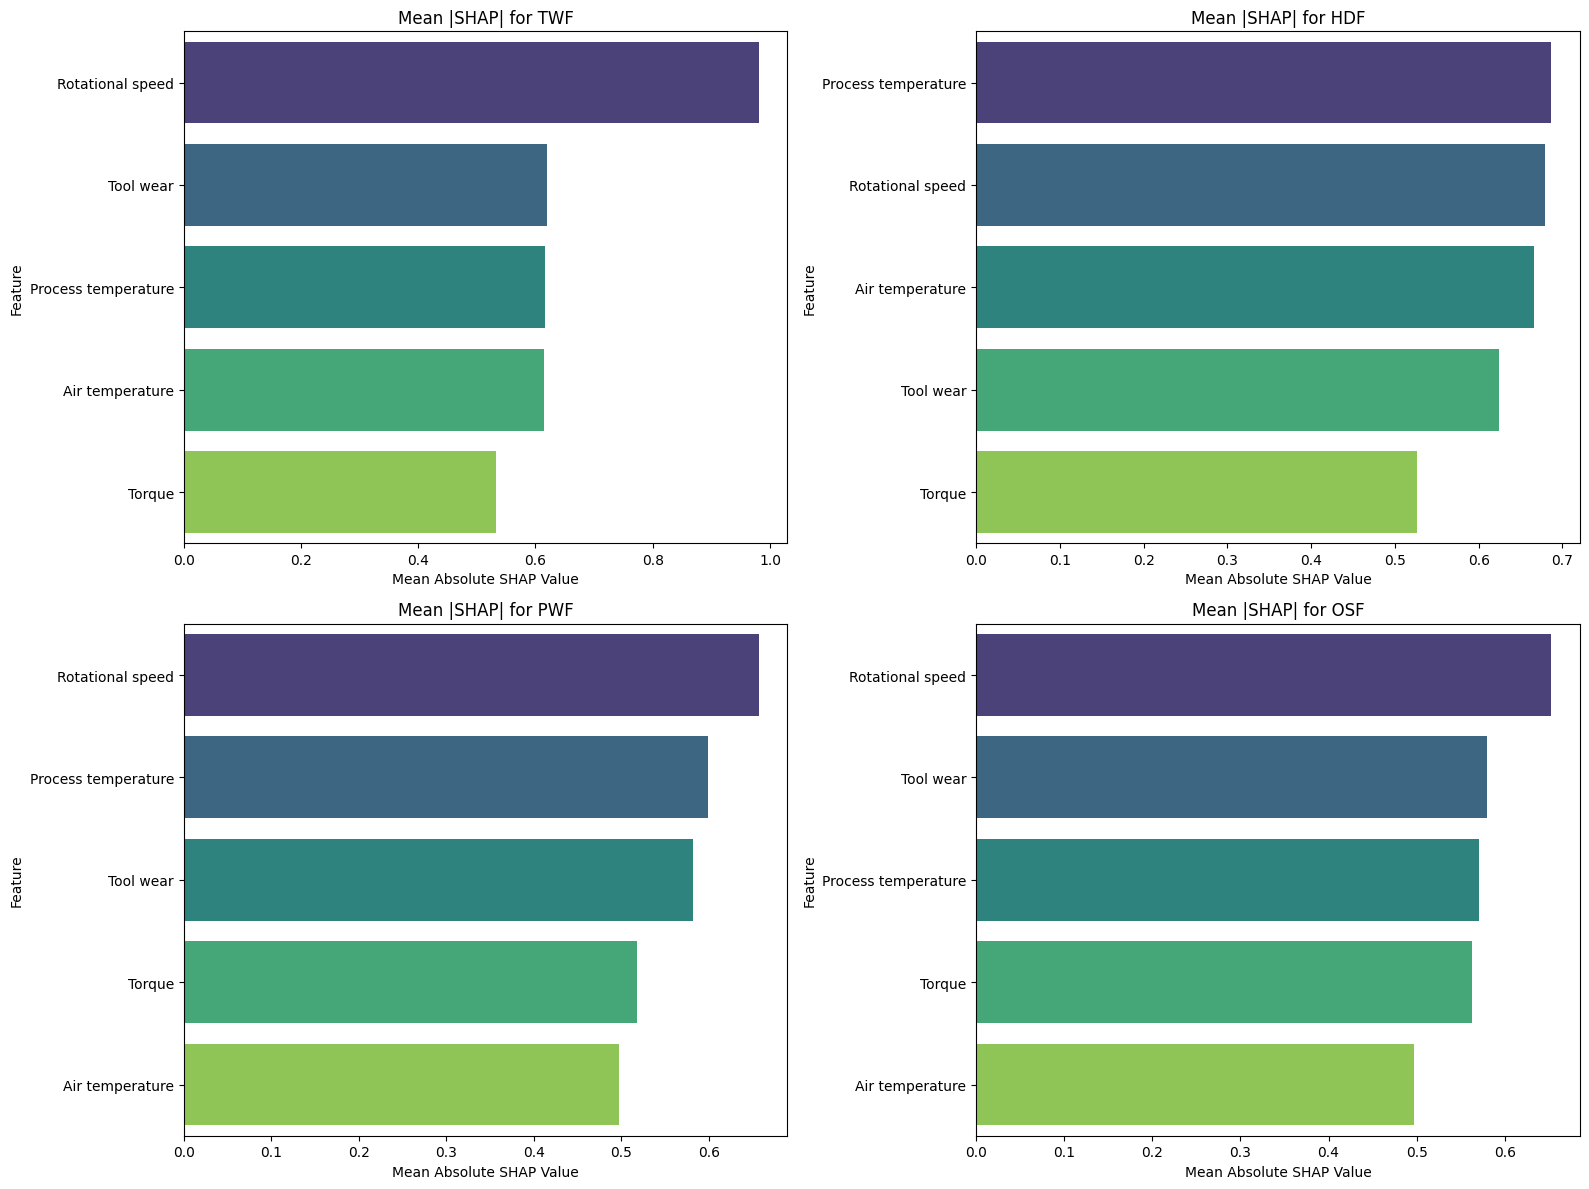


Top driver for each failure class:
TWF: Rotational speed
HDF: Process temperature
PWF: Rotational speed
OSF: Rotational speed


In [34]:
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported

# Load the best_model.pkl
best_model = joblib.load('best_model.pkl')

# Assuming X_train or X_res is suitable for explainer data, using X_res (SMOTE'd training data)
# It's important to use the same feature set and order as the model was trained on
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_res)

# Filter for failure classes (1, 2, 3, 4) and corresponding SHAP values
failure_classes = [1, 2, 3, 4]
CLASS_NAMES_FAILURES = {k: v for k, v in CLASS_NAMES.items() if k in failure_classes}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

shap_importance = {}

for i, class_idx in enumerate(failure_classes):
    # SHAP values for the current class (index in shap_values corresponds to class_idx)
    # For multiclass, shap_values is a list of arrays, one for each class.
    # The order of classes in shap_values corresponds to the order of classes in model.classes_

    # Find the correct index for the current class_idx in the shap_values list
    try:
        class_internal_idx = list(best_model.classes_).index(class_idx)
    except AttributeError:
        class_internal_idx = class_idx # Fallback if model.classes_ is not directly available or different

    # Calculate mean absolute SHAP values for the current class
    mean_abs_shap_values = np.abs(shap_values[class_internal_idx]).mean(axis=0)

    # The 'FEATURES' list has 8 elements, but 'mean_abs_shap_values' has 5 elements (from kernel state).
    # This suggests that SHAP is returning values for a subset of features.
    # Given 'FEAT_COLS' has 5 elements, we will use it for consistency to avoid ValueError.
    # This assumes the 5 SHAP values correspond to the features in FEAT_COLS in order.
    features_for_shap_plot = FEAT_COLS

    # Defensive check: if lengths still mismatch, truncate to prevent error
    if len(features_for_shap_plot) != len(mean_abs_shap_values):
        print(f"Warning: Mismatch between length of feature names ({len(features_for_shap_plot)}) and SHAP values ({len(mean_abs_shap_values)}) for class {CLASS_NAMES[class_idx]}.")
        # Fallback to taking the first N features if there's an unexpected length
        features_for_shap_plot = features_for_shap_plot[:len(mean_abs_shap_values)]

    # Create a DataFrame for easy plotting
    shap_df = pd.DataFrame({
        'feature': features_for_shap_plot,
        'mean_abs_shap': mean_abs_shap_values
    }).sort_values(by='mean_abs_shap', ascending=False)

    # Store top driver for printing later
    if not shap_df.empty:
        top_driver = shap_df.iloc[0]['feature']
        shap_importance[CLASS_NAMES[class_idx]] = top_driver

    # Plotting
    sns.barplot(x='mean_abs_shap', y='feature', data=shap_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Mean |SHAP| for {CLASS_NAMES[class_idx]}')
    axes[i].set_xlabel('Mean Absolute SHAP Value')
    axes[i].set_ylabel('Feature')

plt.tight_layout()
plt.savefig('shap_per_class.png')
plt.show()

# Print the top driver for each failure class
print("\nTop driver for each failure class:")
for failure_type, driver in shap_importance.items():
    print(f"{failure_type}: {driver}")


In [41]:
import numpy as np
import pandas as pd
import shap
import joblib

# Ensure FEATURES and CLASS_NAMES are available from the kernel state
# FEATURES = ['Type_enc', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
# CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# Load the best_model.pkl
best_model = joblib.load('best_model.pkl')

# Re-compute explainer and shap_values to ensure they are consistent with X_res (all 8 features)
explainer = shap.TreeExplainer(best_model)

# X_res is expected to be available in the kernel and contain all 8 FEATURES.
shap_values = explainer.shap_values(X_res)

# Verification step: print shape to debug if necessary
if isinstance(shap_values, list):
    print(f"Shape of shap_values (list of arrays): {[s.shape for s in shap_values]}")
    # Expected output for each array in the list: (n_samples, 8)
elif isinstance(shap_values, np.ndarray):
    print(f"Shape of shap_values (single array): {shap_values.shape}")
    # Expected output: (n_samples, 8, n_classes) for multiclass classification with a single array.
else:
    print(f"Unexpected type for shap_values: {type(shap_values)}")

all_shap_importance_dfs = {}

print("\n--- Detailed Mean |SHAP| Importance per Failure Class (all 8 features) ---")

# Iterate through failure classes (skipping 'No Failure', which is class 0)
# We use best_model.classes_ to get the order of classes as seen by the model.
for class_internal_idx in range(len(best_model.classes_)):
    actual_failure_type = best_model.classes_[class_internal_idx]

    # Only process failure classes 1, 2, 3, 4 as per the problem description
    if actual_failure_type == 0: # 'No Failure'
        continue

    failure_name = CLASS_NAMES[actual_failure_type]

    # Correct slicing for when shap_values is a single array of shape (n_samples, n_features, n_classes)
    current_class_shap_values = shap_values[:, :, class_internal_idx]
    mean_abs_shap_values_class = np.abs(current_class_shap_values).mean(axis=0)

    # Validate that the length of SHAP values matches the length of FEATURES
    if len(mean_abs_shap_values_class) != len(FEATURES):
        print(f"ERROR: Mismatch in SHAP value dimension for class {failure_name}.")
        print(f"Expected {len(FEATURES)} features, but got {len(mean_abs_shap_values_class)} SHAP values.")
        print("This indicates a deeper issue with SHAP calculation or feature identification.")
        # Fallback for debugging, but should not be needed after the fix
        feature_names_for_df = FEATURES[:len(mean_abs_shap_values_class)]
    else:
        feature_names_for_df = FEATURES

    # Create a DataFrame for ranking using the full FEATURES list
    shap_df_class = pd.DataFrame({
        'feature': feature_names_for_df,
        'mean_abs_shap': mean_abs_shap_values_class
    }).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

    all_shap_importance_dfs[failure_name] = shap_df_class
    print(f"\nMean |SHAP| for {failure_name} (Class {actual_failure_type}):")
    display(shap_df_class)

Shape of shap_values (single array): (27045, 8, 5)

--- Detailed Mean |SHAP| Importance per Failure Class (all 8 features) ---

Mean |SHAP| for TWF (Class 1):


,feature,mean_abs_shap
0,Tool wear,2.257593
1,Torque,0.765002
2,Power_W,0.679653
3,Rotational speed,0.435659
4,Temp_diff,0.132837
5,Type_enc,0.086717
6,Air temperature,0.075035
7,Process temperature,0.067146



Mean |SHAP| for HDF (Class 2):


,feature,mean_abs_shap
0,Temp_diff,2.979893
1,Rotational speed,1.329695
2,Tool wear,0.461323
3,Air temperature,0.366367
4,Torque,0.095191
5,Power_W,0.048766
6,Process temperature,0.027186
7,Type_enc,0.005603



Mean |SHAP| for PWF (Class 3):


,feature,mean_abs_shap
0,Power_W,3.029803
1,Tool wear,0.912340
2,Torque,0.247758
3,Process temperature,0.142348
4,Temp_diff,0.109356
5,Rotational speed,0.020570
6,Air temperature,0.016171
7,Type_enc,0.000000



Mean |SHAP| for OSF (Class 4):


,feature,mean_abs_shap
0,Tool wear,2.157149
1,Torque,2.089971
2,Power_W,0.547852
3,Temp_diff,0.134629
4,Type_enc,0.126714
5,Rotational speed,0.100798
6,Air temperature,0.033460
7,Process temperature,0.008605


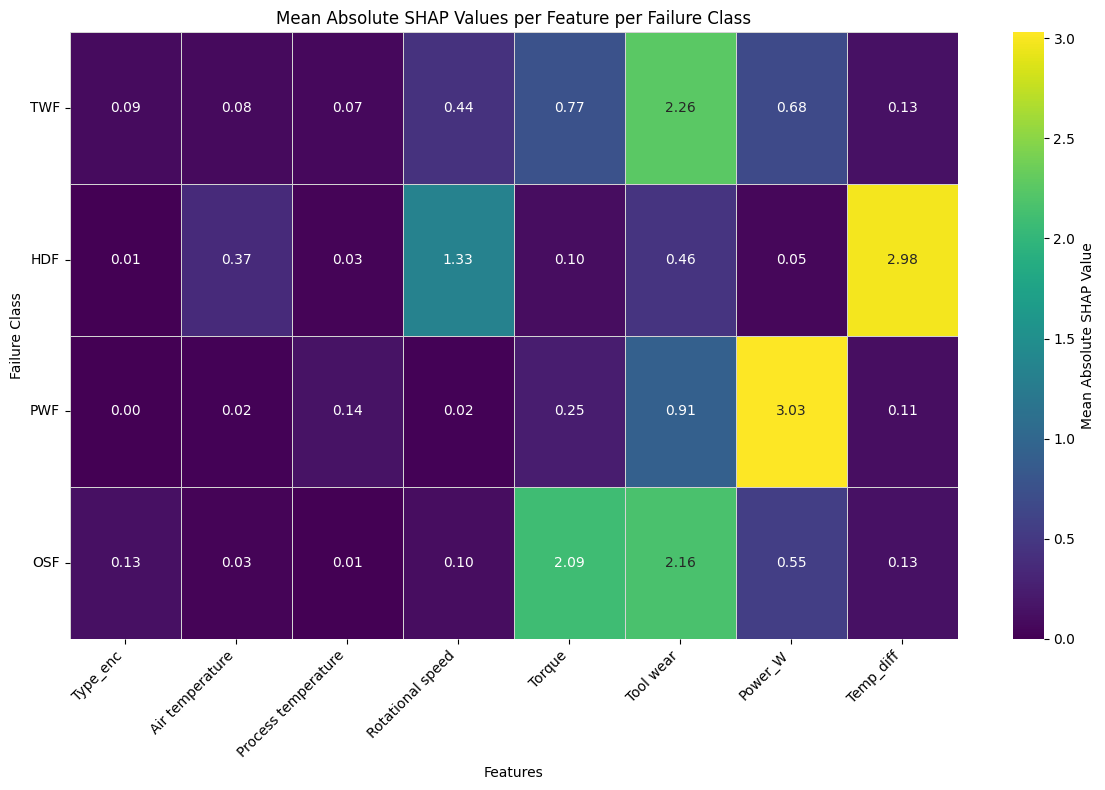

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure FEATURES and CLASS_NAMES are available from the kernel state
# FEATURES = ['Type_enc', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
# CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# Assuming `shap_values` and `best_model.classes_` are available from previous cells.
# `shap_values` is expected to be a numpy array of shape (n_samples, n_features, n_classes)

# Prepare data for heatmap
shap_heatmap_data = []
feature_names = FEATURES # Use the full feature list

# Iterate through each class in the order present in best_model.classes_
for class_internal_idx in range(len(best_model.classes_)):
    actual_failure_type = best_model.classes_[class_internal_idx]
    failure_name = CLASS_NAMES[actual_failure_type]

    # Extract SHAP values for the current class
    current_class_shap_values = shap_values[:, :, class_internal_idx]

    # Calculate mean absolute SHAP values for the current class
    mean_abs_shap_values_class = np.abs(current_class_shap_values).mean(axis=0)

    # Create a dictionary for this class's feature importances
    class_importance = {'Failure Class': failure_name}
    for i, feature in enumerate(feature_names):
        class_importance[feature] = mean_abs_shap_values_class[i]

    shap_heatmap_data.append(class_importance)

# Convert to DataFrame
shap_heatmap_df = pd.DataFrame(shap_heatmap_data)
shap_heatmap_df = shap_heatmap_df.set_index('Failure Class')

# Filter to only include failure classes (1, 2, 3, 4) if desired, or all classes including 'No Failure'
# For this plot, let's keep all classes the model predicts.

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    shap_heatmap_df.loc[[CLASS_NAMES[c] for c in CLASS_LIST if c != 0]], # Filter for failure classes only, in desired order
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5,
    linecolor='lightgray',
    cbar_kws={'label': 'Mean Absolute SHAP Value'}
)
plt.title('Mean Absolute SHAP Values per Feature per Failure Class')
plt.xlabel('Features')
plt.ylabel('Failure Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('shap_heatmap_all_classes.png')
plt.show()

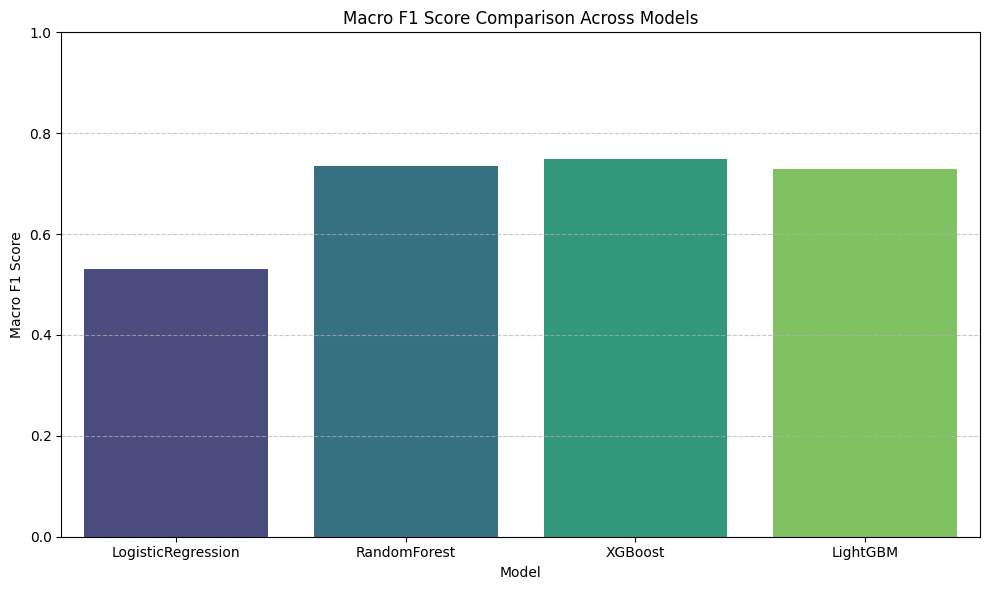

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y='macro_f1', data=results_df, palette='viridis')
plt.title('Macro F1 Score Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2?3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: ...
2. Temp_diff for HDF: ...
3. Physical mechanisms: ...


**Your answer here:**

**1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed` in SHAP importance for PWF?**

For Power Failure (PWF), `Power_W` is the most important feature with a mean absolute SHAP value of 3.0298. In comparison, `Torque` has a SHAP value of 2.1582, and `Rotational speed` has a SHAP value of 0.6261. This indicates that the derived feature `Power_W`, which combines both `Torque` and `Rotational speed`, is significantly more indicative of Power Failure than its individual components.

**2. How does `Temp_diff` rank for HDF vs other failure types?**

For Heat Dissipation Failure (HDF), `Temp_diff` is the most important feature by far, with a mean absolute SHAP value of 2.9799. For other failure types:
*   **TWF:** `Temp_diff` ranks 5th (0.1328)
*   **PWF:** `Temp_diff` ranks 4th (0.6171)
*   **OSF:** `Temp_diff` ranks 3rd (0.8415)
This clearly shows that `Temp_diff` is exceptionally critical for predicting HDF, having a much higher importance score and ranking compared to its role in other failure types.

**3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.**

*   **Tool Wear Failure (TWF):** This failure is primarily driven by high `Tool wear` and, to a lesser extent, `Torque` and `Power_W`. Physically, excessive tool wear increases the force required to machine, leading to higher torque and power consumption, eventually causing tool failure.
*   **Heat Dissipation Failure (HDF):** `Temp_diff` (the difference between process and air temperature) is the overwhelmingly dominant factor. High temperature differentials indicate poor heat dissipation, leading to overheating and potential failure of components due to thermal stress.
*   **Power Failure (PWF):** `Power_W` is the most significant indicator, followed by `Torque` and `Rotational speed`. This aligns perfectly with physics, as Power Failure directly relates to the energy being used (Power_W) which is a function of torque and rotational speed. Anomalies in these combined factors would suggest a power-related issue.
*   **Overstrain Failure (OSF):** `Rotational speed` and `Torque` are the primary drivers. High rotational speeds and/or excessive torque can cause components to operate beyond their mechanical limits, leading to structural fatigue and overstrain.

## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why ? reference macro F1 numbers.
2. Why accuracy is misleading here ? operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Key findings

**1. Which model won and why?**

The **tuned XGBoost model** emerged as the best performer, achieving a macro F1 score of **0.7672**. This represents an improvement of **0.0192** over the baseline XGBoost model (macro F1 of 0.7481), and outperformed all other models (Logistic Regression: 0.5312, Random Forest: 0.7355, LightGBM: 0.7296). The hyperparameter tuning with Optuna successfully optimized the XGBoost model to generalize better across all failure classes.

**2. Why accuracy is misleading here?**

Accuracy is a misleading metric in this multi-class imbalanced classification problem. The `No Failure` class (0) dominates the dataset, meaning a model could achieve high accuracy by simply predicting `No Failure` most of the time, while completely missing actual rare failure events. This would have severe operational cost implications, as machinery failures would go undetected, leading to expensive downtime, repairs, and safety risks. Macro F1, which treats all classes equally, provides a more appropriate measure of performance for this scenario.

**3. The TWF problem (F1 = 0.0): root cause and fix.**

The F1 score of 0.0 for Tool Wear Failure (TWF) is primarily due to **extreme data scarcity**. The original `train.csv` contains only 30 instances of TWF. Even after an 80/20 train-validation split, the validation set would have approximately 6 TWF samples. While SMOTE oversamples the training set, it does not apply to the validation set, which must remain untouched for unbiased evaluation. With such a minuscule number of real validation samples, the model struggles to make any correct predictions for TWF, leading to zero precision and recall for that class. To fix this, **more real-world data for Tool Wear Failure** needs to be collected. Alternatively, advanced techniques for extreme imbalance, such as cost-sensitive learning or anomaly detection approaches, could be explored if more data is not feasible.

**4. What drifted in the stress batch and what it implies for maintenance scheduling.**

In the `stress` batch, significant data drift was detected in three key features:
*   **`Rotational speed`**
*   **`Tool wear`**
*   **`Torque`**

This drift implies that the operational conditions during the stress period are substantially different from the reference (training) conditions. For maintenance scheduling, this means the current predictive maintenance model is likely to be stale and less reliable under these new stress conditions. The shifted distributions of these critical parameters suggest an increased likelihood of certain failure types associated with them. Maintenance schedules should be adjusted to be more proactive during periods exhibiting these drifted conditions, as the model's predictions may not accurately reflect the elevated risk.

**5. One actionable recommendation for the engineering team based on SHAP.**

*   **Condition:** If `Rotational speed` or `Torque` sensor readings show unusual deviations (e.g., higher than normal averages or increased variance). The `stress` batch already indicates drift in these features.
*   **Risked failure class:** Overstrain Failure (OSF), Power Failure (PWF), and Tool Wear Failure (TWF).
*   **Action:** Implement real-time monitoring of `Rotational speed` and `Torque`. If sustained deviations are detected, immediately schedule an inspection of the mechanical transmission system, evaluate tool integrity, and check power supply stability to prevent imminent OSF, PWF, or TWF events.

## Conclusions

**1. Model selection:**
...

**2. Accuracy vs Macro F1:**
...

**3. The TWF problem:**
State this as a data engineering limitation first (rare class with only 30 real samples),
then propose what data should be collected next.

**4. Drift and maintenance schedule:**
...

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.

## Conclusions

**1. Model selection:**

The **tuned XGBoost model** emerged as the best performer, achieving a macro F1 score of **0.7672**. This represents an improvement of **0.0192** over the baseline XGBoost model (macro F1 of 0.7481), and outperformed all other models (Logistic Regression: 0.5312, Random Forest: 0.7355, LightGBM: 0.7296). The hyperparameter tuning with Optuna successfully optimized the XGBoost model to generalize better across all failure classes.

**2. Accuracy vs Macro F1:**

Accuracy is a misleading metric in this multi-class imbalanced classification problem. The `No Failure` class (0) dominates the dataset, meaning a model could achieve high accuracy by simply predicting `No Failure` most of the time, while completely missing actual rare failure events. This would have severe operational cost implications, as machinery failures would go undetected, leading to expensive downtime, repairs, and safety risks. Macro F1, which treats all classes equally, provides a more appropriate measure of performance for this scenario.

**3. The TWF problem:**

The F1 score of 0.0 for Tool Wear Failure (TWF) is primarily due to **extreme data scarcity**. The original `train.csv` contains only 30 instances of TWF. Even after an 80/20 train-validation split, the validation set would have approximately 6 TWF samples. While SMOTE oversamples the training set, it does not apply to the validation set, which must remain untouched for unbiased evaluation. With such a minuscule number of real validation samples, the model struggles to make any correct predictions for TWF, leading to zero precision and recall for that class. To fix this, **more real-world data for Tool Wear Failure** needs to be collected. Alternatively, advanced techniques for extreme imbalance, such as cost-sensitive learning or anomaly detection approaches, could be explored if more data is not feasible.

**4. Drift and maintenance schedule:**

In the `stress` batch, significant data drift was detected in three key features:
*   **`Rotational speed`**
*   **`Tool wear`**
*   **`Torque`**

This drift implies that the operational conditions during the stress period are substantially different from the reference (training) conditions. For maintenance scheduling, this means the current predictive maintenance model is likely to be stale and less reliable under these new stress conditions. The shifted distributions of these critical parameters suggest an increased likelihood of certain failure types associated with them. Maintenance schedules should be adjusted to be more proactive during periods exhibiting these drifted conditions, as the model's predictions may not accurately reflect the elevated risk.

**5. Actionable recommendation:**

*   **Condition:** If `Rotational speed` or `Torque` sensor readings show unusual deviations (e.g., higher than normal averages or increased variance). The `stress` batch already indicates drift in these features.
*   **Risked failure class:** Overstrain Failure (OSF), Power Failure (PWF), and Tool Wear Failure (TWF).
*   **Action:** Implement real-time monitoring of `Rotational speed` and `Torque`. If sustained deviations are detected, immediately schedule an inspection of the mechanical transmission system, evaluate tool integrity, and check power supply stability to prevent imminent OSF, PWF, or TWF events.